<a href="https://colab.research.google.com/github/donkey-king-kong/CSCI-4364-ML/blob/setup/CSCI_4634_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup
- Mounting of Google Drive
- Mounting of Google Drive

## Note
- The extracted labels and images are stored at runtime
- This cell needs to **re-run** with each new session to obtain dataset
- Cell runtime is fairly fast $\approx \text{3 minutes}$

In [ ]:
import zipfile
import os
import time

# Mount GDrive
from google.colab import drive
drive.mount('/content/drive')

# Base paths in Google Drive and Colab
base_zip_dir = "/content/drive/MyDrive/(GWU ML) CSCI-4364 Project/Dataset"
base_extract_dir = "/content/data"

# Zip files and target folders
archives = [
    {
        "name": "labels",
        "zip_path": f"{base_zip_dir}/bdd100k_labels.zip",
        "extract_path": f"{base_extract_dir}/100k_labels",
    },
    {
        "name": "images",
        "zip_path": f"{base_zip_dir}/bdd100k_images_100k.zip",
        "extract_path": f"{base_extract_dir}/100k_images",
    },
]

for item in archives:
    name = item["name"]
    zip_path = item["zip_path"]
    extract_path = item["extract_path"]

    os.makedirs(extract_path, exist_ok=True)

    start = time.time()
    print(f"Extracting {name} from {zip_path} to {extract_path}...")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    print(f"Finished extracting {name} in {(time.time() - start) / 60:.2f} minutes\n")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting labels from /content/drive/MyDrive/(GWU ML) CSCI-4364 Project/Dataset/bdd100k_labels.zip to /content/data/100k_labels...
Finished extracting labels in 0.63 minutes

Extracting images from /content/drive/MyDrive/(GWU ML) CSCI-4364 Project/Dataset/bdd100k_images_100k.zip to /content/data/100k_images...
Finished extracting images in 1.52 minutes



# Data Preprocessing

In [24]:
import json
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

In [25]:
class LargestCarDataset(Dataset):
    def __init__(self, image_dir, label_dir):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transforms.ToTensor()
        self.samples = []

        for label_file in os.listdir(label_dir):
            if not label_file.endswith(".json"):
                continue

            label_path = os.path.join(label_dir, label_file)

            with open(label_path, "r") as f:
                data = json.load(f)

            image_name = data.get("name")
            if image_name is None:
                continue

            image_path = os.path.join(image_dir, image_name + ".jpg")
            if not os.path.exists(image_path):
                continue

            frames = data.get("frames", [])
            if len(frames) == 0:
                continue

            objects = frames[0].get("objects", [])

            largest_box = None
            largest_area = 0

            for obj in objects:
                if obj.get("category") != "car":
                    continue

                box = obj.get("box2d")
                if box is None:
                    continue

                x1, y1, x2, y2 = box["x1"], box["y1"], box["x2"], box["y2"]
                area = (x2 - x1) * (y2 - y1)

                if area > largest_area:
                    largest_area = area
                    largest_box = [x1, y1, x2, y2]

            if largest_box is not None:
                self.samples.append((image_path, largest_box))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, bbox = self.samples[idx]

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        bbox = torch.tensor(bbox, dtype=torch.float32)

        return image, bbox

In [26]:
train_image_dir = "/content/data/100k_images/100k/train"
train_label_dir = "/content/data/100k_labels/100k/train"

dataset = LargestCarDataset(train_image_dir, train_label_dir)
print(len(dataset))

69201


## Sample Visualisation

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_sample(dataset, idx):
    image, bbox = dataset[idx]

    # Convert tensor to numpy
    img = image.permute(1, 2, 0).numpy()

    x1, y1, x2, y2 = bbox

    fig, ax = plt.subplots(1)
    ax.imshow(img)

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(rect)
    plt.show()

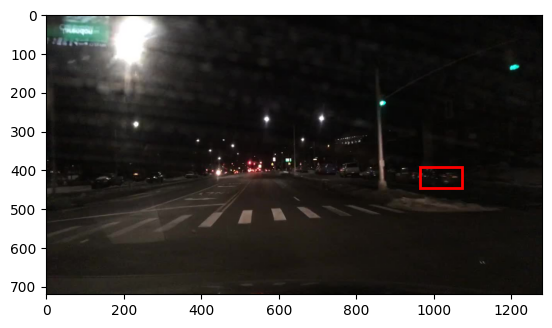

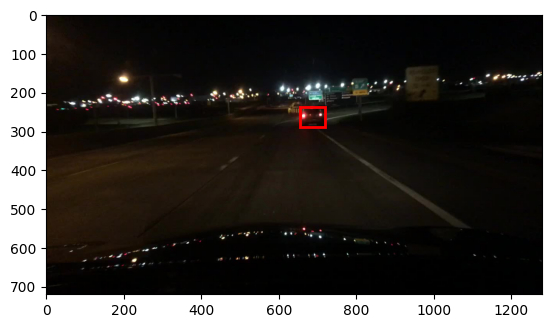

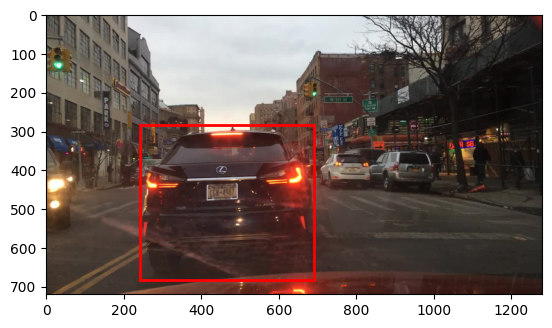

In [28]:
visualize_sample(dataset, 0)
visualize_sample(dataset, 10)
visualize_sample(dataset, 100)